In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_nsl_kdd

In [2]:
train_data = load_nsl_kdd("../data/raw/KDDTrain+.txt")
test_data = load_nsl_kdd("../data/raw/KDDTest+.txt")

print("Training shape:", train_data.shape)
print("Test shape:", test_data.shape)

Training shape: (125973, 43)
Test shape: (22544, 43)


In [3]:
print("First 5 rows:")
display(train_data.head())

print("\nColumn names:")
print(train_data.columns.tolist())

print("\nData types:")
print(train_data.dtypes)

print("\nMissing values:")
print(train_data.isnull().sum())

First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21



Column names:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty']

Data types:
duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                

In [4]:
label_counts = train_data["label"].value_counts()

print("Attack type counts:")
print(label_counts)

normal_count = (train_data["label"] == "normal").sum()
attack_count = (train_data["label"] != "normal").sum()
total_count = len(train_data)

print("\nNormal connections:", normal_count)
print("Attack connections:", attack_count)

print("\nNormal percentage:", round(normal_count / total_count * 100, 2), "%")
print("Attack percentage:", round(attack_count / total_count * 100, 2), "%")

Attack type counts:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Normal connections: 67343
Attack connections: 58630

Normal percentage: 53.46 %
Attack percentage: 46.54 %


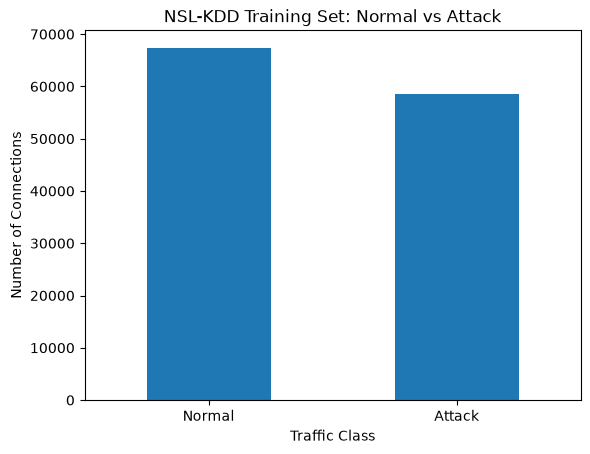

In [5]:
class_counts = pd.Series({
    "Normal": normal_count,
    "Attack": attack_count
})

class_counts.plot(kind="bar")

plt.title("NSL-KDD Training Set: Normal vs Attack")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Connections")
plt.xticks(rotation=0)
plt.show()

In [6]:
summary_stats = train_data.describe()

display(summary_stats)

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


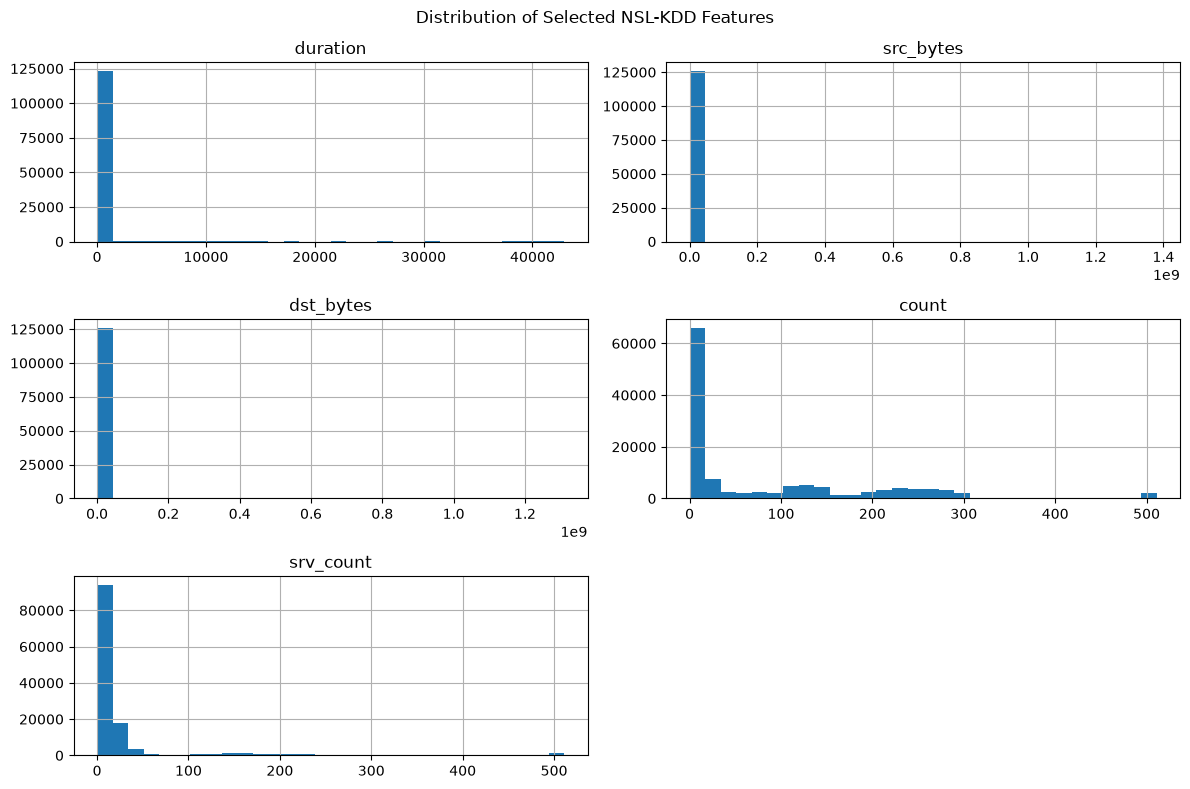

In [7]:
features = ["duration", "src_bytes", "dst_bytes", "count", "srv_count"]

train_data[features].hist(bins=30, figsize=(12, 8))

plt.suptitle("Distribution of Selected NSL-KDD Features")
plt.tight_layout()
plt.show()

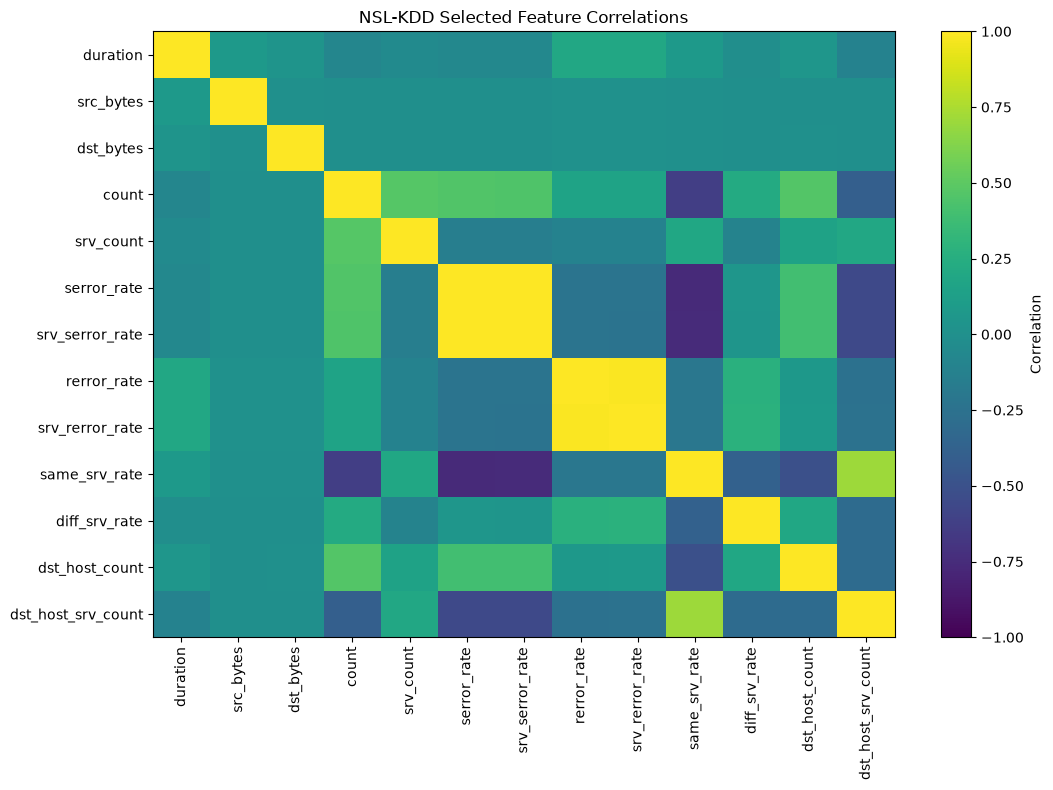

In [11]:
selected_features = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "dst_host_count",
    "dst_host_srv_count"
]

correlation_matrix = train_data[selected_features].corr()

plt.figure(figsize=(11, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(selected_features)),
    selected_features,
    rotation=90
)

plt.yticks(
    range(len(selected_features)),
    selected_features
)

plt.title("NSL-KDD Selected Feature Correlations")
plt.tight_layout()
plt.show()

## EDA Summary

- The NSL-KDD training dataset contains 125,973 network connections and 43 columns.
- No missing values were found in the training data.
- The training data contains 67,343 normal connections and 58,630 attack connections.
- Normal traffic makes up about 53.46% of the training data, while attack traffic makes up about 46.54%.
- Several numerical features, including duration, src_bytes, and dst_bytes, are heavily skewed and contain large values compared with most observations.
- The correlation heatmap shows that some network traffic features are strongly related, especially several count and error-rate features.
- These results will help guide preprocessing and feature preparation before the anomaly detection models are trained.